In [63]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input # type: ignore
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D # type: ignore
from tensorflow.keras.models import Model # type: ignore
from tensorflow.keras.optimizers import Adam # type: ignore
from keras.callbacks import ModelCheckpoint # type: ignore
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [64]:
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    for device in physical_devices:
        tf.config.experimental.set_memory_growth(device, True)

tf.keras.mixed_precision.set_global_policy('mixed_float16')

In [65]:
# Constants
BASE_DIR = "./content/Training"
TUMOR_DIR = os.path.join(BASE_DIR, "Tumor")
STROKE_DIR = os.path.join(BASE_DIR, "Stroke")
ALL_IMAGES_DIR = os.path.join(BASE_DIR, "AllImages")
CSV_PATH = "labels.csv"

resize_width = 224
resize_height = 224

In [66]:
# Create the "AllImages" directory if it doesn't exist
os.makedirs(ALL_IMAGES_DIR, exist_ok=True)

# Initialize lists to store filenames and labels
filenames = []
tumor_labels = []
stroke_labels = []

In [67]:
# Function to process images and create labels
def process_images(sub_dir, label_column):
    for class_label in ['yes', 'no']:
        class_path = os.path.join(sub_dir, class_label)
        if not os.path.exists(class_path):
            continue  # Skip if the directory doesn't exist
        for img_name in os.listdir(class_path):
            src = os.path.join(class_path, img_name)
            dst = os.path.join(ALL_IMAGES_DIR, img_name)
            if not os.path.exists(dst):  # Avoid overwriting files
                os.rename(src, dst)  # Move images to AllImages
            filenames.append(img_name)
            if label_column == 'tumor':
                tumor_labels.append(1 if class_label == 'yes' else 0)
                stroke_labels.append(0)  # Default for stroke
            elif label_column == 'stroke':
                stroke_labels.append(1 if class_label == 'yes' else 0)
                tumor_labels.append(0)  # Default for tumor

# Process images for both tumor and stroke
process_images(TUMOR_DIR, 'tumor')
process_images(STROKE_DIR, 'stroke')

In [68]:
# Create a DataFrame with the filenames and labels
df = pd.DataFrame({
    'filename': filenames,
    'tumor': tumor_labels,
    'stroke': stroke_labels
})

# Drop duplicates in case an image belongs to both classes
df = df.drop_duplicates(subset=['filename'])

# Save DataFrame to a CSV file
df.to_csv(CSV_PATH, index=False)

In [69]:
# Load labels from the CSV
df = pd.read_csv(CSV_PATH)

# Split dataset into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print("Train DF: ", train_df)
print("Val DF: ", val_df)

Train DF:            filename  tumor  stroke
261    58 (19).jpg      0       1
809    83 (18).jpg      0       1
1405  106 (24).jpg      0       0
1786  119 (23).jpg      0       0
727    80 (30).jpg      0       1
...            ...    ...     ...
1638  114 (26).jpg      0       0
1095   92 (34).jpg      0       1
1130   93 (35).jpg      0       1
1294   102 (9).jpg      0       0
860    84 (39).jpg      0       1

[2203 rows x 3 columns]
Val DF:            filename  tumor  stroke
2740   99 (23).jpg      0       0
1911  123 (29).jpg      0       0
1263   101 (9).jpg      0       0
1456  108 (17).jpg      0       0
2254    52 (3).jpg      0       0
...            ...    ...     ...
315     66 (9).jpg      0       1
798     82 (8).jpg      0       1
759    81 (35).jpg      0       1
568    75 (14).jpg      0       1
644    77 (38).jpg      0       1

[551 rows x 3 columns]


In [70]:
# Data generators for training and validation
train_data_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20
)

val_data_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

print("Train data generator: ", train_data_gen)
print("Val data generator: ", val_data_gen)

# Create training and validation generators
train_generator = train_data_gen.flow_from_dataframe(
    train_df,
    ALL_IMAGES_DIR,
    x_col='filename',
    y_col=['tumor', 'stroke'],  # Multi-label
    target_size=(resize_width, resize_height),
    color_mode='rgb',
    class_mode=None,  # No automatic label handling
    batch_size=32,
    shuffle=True
)

validation_generator = val_data_gen.flow_from_dataframe(
    val_df,
    ALL_IMAGES_DIR,
    x_col='filename',
    y_col=['tumor', 'stroke'],  # Multi-label
    target_size=(resize_width, resize_height),
    color_mode='rgb',
    class_mode=None,  # No automatic label handling
    batch_size=32,
    shuffle=False
)

train_labels = train_df[['tumor', 'stroke']].values
val_labels = val_df[['tumor', 'stroke']].values

# Class mapping is now not necessary as labels are separate
# But you can still print some info
print("Training samples:", train_generator.samples)
print("Validation samples:", validation_generator.samples)

print("Train labels shape:", train_labels.shape)
print("Validation labels shape:", val_labels.shape)

Train data generator:  <keras.src.legacy.preprocessing.image.ImageDataGenerator object at 0x0000013C431B5670>
Val data generator:  <keras.src.legacy.preprocessing.image.ImageDataGenerator object at 0x0000013C431BAD50>
Found 2203 validated image filenames.
Found 551 validated image filenames.
Training samples: 2203
Validation samples: 551
Train labels shape: (2203, 2)
Validation labels shape: (551, 2)


In [71]:
# Custom data generator
def custom_data_generator(image_generator, labels):
    while True:
        images = next(image_generator)
        batch_size = images.shape[0]  # Current batch size (could be smaller than expected for the last batch)
        yield images, {
            'tumor_output': labels[:batch_size, 0],
            'stroke_output': labels[:batch_size, 1]
        }

train_gen = custom_data_generator(train_generator, train_labels)
val_gen = custom_data_generator(validation_generator, val_labels)

In [72]:
# Load the VGG16 model without the top layer
vgg = VGG16(weights="imagenet", include_top=False, input_shape=(resize_width, resize_height, 3))

# Freeze the base model layers
for layer in vgg.layers:
    layer.trainable = False

In [73]:
# Add custom layers for multi-task learning
def structure_model(bottom_model):
    top_model = bottom_model.output
    top_model = GlobalAveragePooling2D()(top_model)
    top_model = Dense(1024, activation='relu')(top_model)
    top_model = Dense(512, activation='relu')(top_model)
    return top_model

# Create shared layers
model_head = structure_model(vgg)

tumor_output = Dense(1, activation='sigmoid', name='tumor_output')(model_head)
stroke_output = Dense(1, activation='sigmoid', name='stroke_output')(model_head)

In [74]:
# Build the final model
model = Model(inputs=vgg.input, outputs=[tumor_output, stroke_output])

# Compile the model
opt = Adam(learning_rate=0.0001)
model.compile(
    loss={
        'tumor_output': 'binary_crossentropy',
        'stroke_output': 'binary_crossentropy'
    },
    optimizer=opt,
    metrics={
        'tumor_output': 'accuracy',
        'stroke_output': 'accuracy'
    }
)

# Print model summary
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_5 (Cast)       │ (None, 128, 128,  │          0 │ input_layer_5[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 128, 128,  │      1,792 │ cast_5[0][0]      │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 128, 128,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 64, 64,    │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 64, 64,    │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 64, 64,    │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 32, 32,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 32, 32,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 32, 32,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 32, 32,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 16, 16,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 16, 16,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 16, 16,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 16, 16,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 8, 8, 512) │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 8, 8, 512) │  2,359,808 │ block4_pool[0][0

 Total params: 15,765,826 (60.14 MB)

 Trainable params: 1,051,138 (4.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [75]:
# Define checkpoint callback
checkpoint = ModelCheckpoint('model/best_model.keras', save_best_only=True, monitor='val_loss')

cp = ModelCheckpoint(
    filepath='model_checkpoint.keras',
    save_best_only=True,
    monitor='val_loss',
    mode='min'
)

steps_per_epoch = int(np.ceil(train_generator.samples / train_generator.batch_size))
validation_steps = int(np.ceil(validation_generator.samples / validation_generator.batch_size))

print("Steps per epoch: ", steps_per_epoch)
print("Validation Steps: ", validation_steps)

# Train the model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=10,
    callbacks=[checkpoint]
)

Steps per epoch:  69
Validation Steps:  18
Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - loss: 1.9397 - stroke_output_accuracy: 0.7987 - stroke_output_loss: 0.1138 - tumor_output_accuracy: 0.6470 - tumor_output_loss: 1.8259 - val_loss: 0.7012 - val_stroke_output_accuracy: 0.7840 - val_stroke_output_loss: 1.0455e-05 - val_tumor_output_accuracy: 0.8403 - val_tumor_output_loss: 0.6866
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - loss: 0.5499 - stroke_output_accuracy: 0.8125 - stroke_output_loss: 1.2321e-05 - tumor_output_accuracy: 0.9586 - tumor_output_loss: 0.5499 - val_loss: 0.6821 - val_stroke_output_accuracy: 0.7840 - val_stroke_output_loss: 1.1055e-05 - val_tumor_output_accuracy: 0.9401 - val_tumor_output_loss: 0.6644
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - loss: 0.5658 - stroke_output_accuracy: 0.8125 - stroke_output_loss: 1.7329e-05 - tumor_output_accuracy: 0.9594 - tumor_output_loss: 0.5658 - val_loss: 0.6430 - val_stroke_output_accuracy: 0.7840 - val_stro

In [76]:
# Evaluate model predictions
val_predictions = model.predict(validation_generator)

# Convert predictions to binary labels
predicted_tumor = (val_predictions[0] > 0.5).astype(int).reshape(-1)
predicted_stroke = (val_predictions[1] > 0.5).astype(int).reshape(-1)

# True labels
true_tumor = val_df['tumor'].values
true_stroke = val_df['stroke'].values

# Generate classification reports
print("Classification Report for Tumor Detection:")
print(classification_report(true_tumor, predicted_tumor))

print("Classification Report for Stroke Detection:")
print(classification_report(true_stroke, predicted_stroke))

C:\Users\vaibh\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 932ms/step
Classification Report for Tumor Detection:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       524
           1       0.00      0.00      0.00        27

    accuracy                           0.91       551
   macro avg       0.47      0.48      0.48       551
weighted avg       0.90      0.91      0.91       551

Classification Report for Stroke Detection:
              precision    recall  f1-score   support

           0       0.66      1.00      0.80       364
           1       0.00      0.00      0.00       187

    accuracy                           0.66       551
   macro avg       0.33      0.50      0.40       551
weighted avg       0.44      0.66      0.53       551



C:\Users\vaibh\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vaibh\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vaibh\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

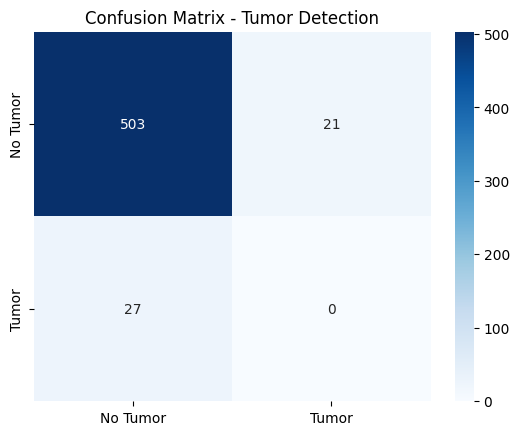

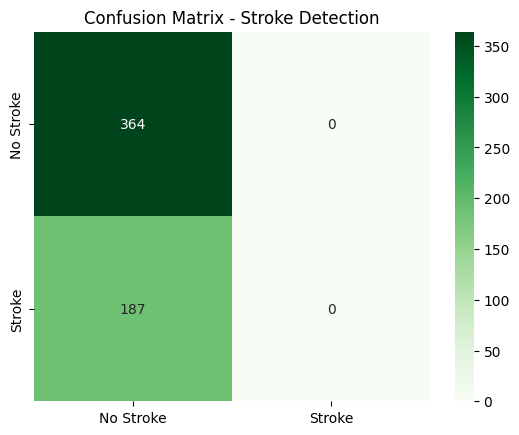

In [77]:
# Confusion matrices
conf_matrix_tumor = confusion_matrix(true_tumor, predicted_tumor)
sns.heatmap(conf_matrix_tumor, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])

plt.title('Confusion Matrix - Tumor Detection')
plt.show()

conf_matrix_stroke = confusion_matrix(true_stroke, predicted_stroke)
sns.heatmap(conf_matrix_stroke, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])

plt.title('Confusion Matrix - Stroke Detection')
plt.show()

In [98]:
# Predict on a sample image
imgToRead = "./content/Training/Stroke/yes/58 (1).jpg"
img = cv2.imread(imgToRead)
img = cv2.resize(img, (resize_width, resize_height), cv2.INTER_LANCZOS4)
img_array = np.array(img)

In [99]:
# Preprocess input image before prediction
img_array = preprocess_input(img_array)

# Reshape the image for prediction
img_array = img_array.reshape(1, resize_width, resize_height, 3)

# Make prediction
predictions = model.predict(img_array)
print("Raw Prediction Output:", predictions)

# Interpret predictions for tumor and stroke
tumor_pred = 'Yes' if predictions[0] > 0.5 else 'No'
stroke_pred = 'Yes' if predictions[1] > 0.5 else 'No'

print(f"Predicted Tumor: {tumor_pred}")
print(f"Predicted Stroke: {stroke_pred}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Raw Prediction Output: [array([[0.665]], dtype=float16), array([[0.]], dtype=float16)]
Predicted Tumor: Yes
Predicted Stroke: No
